In [1]:
import sys
import os

# la racine du projet 
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(ROOT_DIR)

from model.mctnet import MCTNet

print(f" Modèle importé depuis: {os.path.join(ROOT_DIR, 'model', 'mctnet.py')}")

 Modèle importé depuis: c:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\model\mctnet.py


In [2]:
# ============================================
# IMPORTS NÉCESSAIRES POUR LE NOTEBOOK
# ============================================

# === Bibliothèques standard ===
import os
import math
import warnings
warnings.filterwarnings('ignore')

# === Manipulation des données ===
import numpy as np
import pandas as pd

# === Visualisation ===
import matplotlib.pyplot as plt

# === Scikit-learn (prétraitement et métriques) ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score

# === PyTorch ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# === Pour la vérification des données de sol (optionnel) ===
import seaborn as sns

print("✅ Tous les imports sont prêts !")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ Tous les imports sont prêts !
PyTorch version: 2.7.1+cpu
NumPy version: 2.4.3
Pandas version: 3.0.2


In [3]:


# Recharger les covariables depuis le fichier original
data_path = r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned'
covariates = pd.read_csv(f'{data_path}/covariates.csv')

print("=" * 60)
print("DONNÉES RECHARGÉES")
print("=" * 60)
print(f"Shape: {covariates.shape}")
print(f"Colonnes: {covariates.columns.tolist()}")

DONNÉES RECHARGÉES
Shape: (10487, 12)
Colonnes: ['system:index', 'climate_dewpoint_mean', 'climate_precip_total', 'climate_temp_mean', 'file', 'label', 'soil_oc', 'soil_ph', 'soil_texture', 'topo_elevation', 'topo_landforms', '.geo']


In [4]:
print("=" * 60)
print("ONE-HOT ENCODING POUR SOIL_TEXTURE")
print("=" * 60)

# Afficher les valeurs uniques
print(f"\nValeurs uniques de soil_texture: {sorted(covariates['soil_texture'].unique())}")
print(f"Valeurs manquantes: {covariates['soil_texture'].isna().sum()}")

# Remplacer les NaN par la valeur la plus fréquente
mode_value = covariates['soil_texture'].mode()[0]
covariates['soil_texture'] = covariates['soil_texture'].fillna(mode_value)
print(f"✅ NaN remplacés par la mode: {mode_value}")

# One-Hot Encoding
soil_dummies = pd.get_dummies(covariates['soil_texture'], prefix='soil_texture', dtype=np.float32)

print(f"\nNouvelles colonnes créées: {list(soil_dummies.columns)}")

# Ajouter les dummies
covariates = pd.concat([covariates, soil_dummies], axis=1)

# Supprimer l'ancienne colonne
covariates = covariates.drop('soil_texture', axis=1)

print(f"\n✅ soil_texture encodé avec succès!")

ONE-HOT ENCODING POUR SOIL_TEXTURE

Valeurs uniques de soil_texture: [np.float64(4.0), np.float64(7.0), np.float64(nan), np.float64(1.0), np.float64(2.0)]
Valeurs manquantes: 12
✅ NaN remplacés par la mode: 7.0

Nouvelles colonnes créées: ['soil_texture_1.0', 'soil_texture_2.0', 'soil_texture_4.0', 'soil_texture_7.0']

✅ soil_texture encodé avec succès!


# Cellule 1 : Import des bibliothèques

In [5]:
# Colonnes climat # Séparation par catégorie
climate_cols = ['climate_precip_total', 'climate_temp_mean', 'climate_dewpoint_mean']

# Colonnes sol (continues + One-Hot)
soil_continuous_cols = ['soil_ph', 'soil_oc']
soil_onehot_cols = ['soil_texture_1.0', 'soil_texture_2.0', 'soil_texture_4.0', 'soil_texture_7.0']
soil_cols = soil_continuous_cols + soil_onehot_cols

# Colonnes topographie
topo_cols = ['topo_elevation', 'topo_landforms']

# Extraire les features
X_climate = covariates[climate_cols].values
X_soil = covariates[soil_cols].values
X_topo = covariates[topo_cols].values
X_all_cov = covariates[climate_cols + soil_cols + topo_cols].values

print("\n=== FEATURES PAR CATÉGORIE ===")
print(f"Climat ({len(climate_cols)}): {X_climate.shape}")
print(f"Sol (continues: {len(soil_continuous_cols)} + One-Hot: {len(soil_onehot_cols)} = {len(soil_cols)}): {X_soil.shape}")
print(f"Topographie ({len(topo_cols)}): {X_topo.shape}")
print(f"Total covariables ({len(climate_cols) + len(soil_cols) + len(topo_cols)}): {X_all_cov.shape}")


=== FEATURES PAR CATÉGORIE ===
Climat (3): (10487, 3)
Sol (continues: 2 + One-Hot: 4 = 6): (10487, 6)
Topographie (2): (10487, 2)
Total covariables (11): (10487, 11)


# Cellule 3 : Normalisation des données Sentinel-2

In [6]:
# ============================================
# CELLULE 4 - Normalisation des covariables
# ============================================

from sklearn.preprocessing import StandardScaler
import numpy as np

print("=" * 60)
print("NORMALISATION DES COVARIABLES")
print("=" * 60)

# Afficher les colonnes pour vérification
print(f"\nColonnes disponibles: {[c for c in covariates.columns if 'soil' in c or 'climate' in c or 'topo' in c]}")

# 1. Climat
climate_cols = ['climate_precip_total', 'climate_temp_mean', 'climate_dewpoint_mean']
scaler_climate = StandardScaler()
X_climate_norm = scaler_climate.fit_transform(covariates[climate_cols].values)
print(f"✅ Climat: {X_climate_norm.shape}")

# 2. Sol (trouver automatiquement les colonnes)
soil_continuous_cols = ['soil_ph', 'soil_oc']
soil_onehot_cols = [c for c in covariates.columns if c.startswith('soil_texture_')]

print(f"   Colonnes sol continues: {soil_continuous_cols}")
print(f"   Colonnes sol One-Hot: {soil_onehot_cols}")

scaler_soil_continuous = StandardScaler()
X_soil_continuous_norm = scaler_soil_continuous.fit_transform(covariates[soil_continuous_cols].values)
X_soil_onehot = covariates[soil_onehot_cols].values
X_soil_norm = np.hstack([X_soil_continuous_norm, X_soil_onehot])
print(f"✅ Sol: {X_soil_norm.shape}")

# 3. Topographie
topo_cols = ['topo_elevation', 'topo_landforms']
scaler_topo = StandardScaler()
X_topo_norm = scaler_topo.fit_transform(covariates[topo_cols].values)
print(f"✅ Topographie: {X_topo_norm.shape}")

# 4. Toutes
X_all_cov_norm = np.hstack([X_climate_norm, X_soil_norm, X_topo_norm])
print(f"✅ Total covariables: {X_all_cov_norm.shape}")

print("\n✅ Normalisation terminée !")

NORMALISATION DES COVARIABLES

Colonnes disponibles: ['climate_dewpoint_mean', 'climate_precip_total', 'climate_temp_mean', 'soil_oc', 'soil_ph', 'topo_elevation', 'topo_landforms', 'soil_texture_1.0', 'soil_texture_2.0', 'soil_texture_4.0', 'soil_texture_7.0']
✅ Climat: (10487, 3)
   Colonnes sol continues: ['soil_ph', 'soil_oc']
   Colonnes sol One-Hot: ['soil_texture_1.0', 'soil_texture_2.0', 'soil_texture_4.0', 'soil_texture_7.0']
✅ Sol: (10487, 6)
✅ Topographie: (10487, 2)
✅ Total covariables: (10487, 11)

✅ Normalisation terminée !


In [7]:
# ÉTAPE 1 : Recharger les données originales
import pandas as pd
import numpy as np

data_path = r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned'
covariates = pd.read_csv(f'{data_path}/covariates.csv')

print("=" * 60)
print("DONNÉES RECHARGÉES")
print("=" * 60)
print(f"Shape: {covariates.shape}")
print(f"Colonnes: {covariates.columns.tolist()}")
print(f"Valeurs uniques de soil_texture: {sorted(covariates['soil_texture'].unique())}")

DONNÉES RECHARGÉES
Shape: (10487, 12)
Colonnes: ['system:index', 'climate_dewpoint_mean', 'climate_precip_total', 'climate_temp_mean', 'file', 'label', 'soil_oc', 'soil_ph', 'soil_texture', 'topo_elevation', 'topo_landforms', '.geo']
Valeurs uniques de soil_texture: [np.float64(4.0), np.float64(7.0), np.float64(nan), np.float64(1.0), np.float64(2.0)]


In [8]:
from sklearn.preprocessing import OneHotEncoder

print("=" * 60)
print("ONE-HOT ENCODING POUR SOIL_TEXTURE")
print("=" * 60)

# Vérifier que soil_texture existe
if 'soil_texture' not in covariates.columns:
    print("❌ ERREUR: La colonne 'soil_texture' n'existe pas!")
    print("   Veuillez réexécuter l'Étape 1 d'abord.")
else:
    # Afficher les valeurs uniques
    print(f"\nValeurs originales de soil_texture: {sorted(covariates['soil_texture'].unique())}")
    print(f"Valeurs manquantes: {covariates['soil_texture'].isna().sum()}")

    # Remplacer les NaN par la valeur la plus fréquente
    mode_value = covariates['soil_texture'].mode()[0]
    covariates['soil_texture'] = covariates['soil_texture'].fillna(mode_value)
    print(f"✅ NaN remplacés par la mode: {mode_value}")

    # One-Hot Encoding
    encoder = OneHotEncoder(sparse_output=False, dtype=np.float32)
    soil_texture_encoded = encoder.fit_transform(covariates[['soil_texture']])

    # Ajouter les nouvelles colonnes
    for i, category in enumerate(encoder.categories_[0]):
        covariates[f'soil_texture_{int(category)}'] = soil_texture_encoded[:, i]

    # Supprimer l'ancienne colonne
    covariates = covariates.drop('soil_texture', axis=1)

    print(f"\n✅ soil_texture encodé en One-Hot")
    print(f"   Colonnes ajoutées: {[f'soil_texture_{int(c)}' for c in encoder.categories_[0]]}")
    print(f"   Nouvelles colonnes: {[c for c in covariates.columns if 'soil_texture' in c]}")

ONE-HOT ENCODING POUR SOIL_TEXTURE

Valeurs originales de soil_texture: [np.float64(4.0), np.float64(7.0), np.float64(nan), np.float64(1.0), np.float64(2.0)]
Valeurs manquantes: 12
✅ NaN remplacés par la mode: 7.0

✅ soil_texture encodé en One-Hot
   Colonnes ajoutées: ['soil_texture_1', 'soil_texture_2', 'soil_texture_4', 'soil_texture_7']
   Nouvelles colonnes: ['soil_texture_1', 'soil_texture_2', 'soil_texture_4', 'soil_texture_7']


# Cellule 4 : Normalisation des covariables

In [9]:
scaler_climate = StandardScaler()
scaler_soil = StandardScaler()
scaler_topo = StandardScaler()
scaler_all = StandardScaler()

X_climate_norm = scaler_climate.fit_transform(X_climate)
X_soil_norm = scaler_soil.fit_transform(X_soil)
X_topo_norm = scaler_topo.fit_transform(X_topo)
X_all_cov_norm = scaler_all.fit_transform(X_all_cov)

print("✅ Normalisation des covariables terminée")

✅ Normalisation des covariables terminée


In [10]:
# ============================================
# CHARGEMENT DES DONNÉES SENTINEL-2 ET LABELS
# ============================================

import numpy as np
import pandas as pd

# Chemins
data_path = r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned'

# Charger les fichiers
X_s2 = np.load(f'{data_path}/X_sentinel2.npy')
y = np.load(f'{data_path}/y_labels.npy')

print("=" * 60)
print("DONNÉES CHARGÉES")
print("=" * 60)
print(f"X_s2 shape: {X_s2.shape}")  # (10487, 36, 13)
print(f"y shape: {y.shape}")        # (10487,)
print(f"Types dans y: {np.unique(y)}")

DONNÉES CHARGÉES
X_s2 shape: (10487, 36, 13)
y shape: (10487,)
Types dans y: [ 36  57  69  74 204]


# Cellule 5 : Normalisation des données Sentinel-2

In [11]:
# ============================================
# CELLULE 5 (CORRIGÉE) - Normalisation des données Sentinel-2
# Format de sortie: (batch, time_steps, channels) pour MCTNet
# ============================================

print(f"X_s2 shape avant normalisation: {X_s2.shape}")

# X_s2.shape actuel: (4000, 36, 13)
# 36 = time_steps (dates)
# 13 = channels (bandes spectrales)

# Normalisation par bande et par date
X_s2_norm = np.zeros_like(X_s2)

for t in range(X_s2.shape[1]):      # pour chaque pas de temps (36)
    for c in range(X_s2.shape[2]):  # pour chaque bande (13)
        mean = X_s2[:, t, c].mean()
        std = X_s2[:, t, c].std()
        if std > 0:
            X_s2_norm[:, t, c] = (X_s2[:, t, c] - mean) / std
        else:
            X_s2_norm[:, t, c] = X_s2[:, t, c]

print(f"✅ Normalisation Sentinel-2 terminée")
print(f"Shape normalisé: {X_s2_norm.shape}")  # (4000, 36, 13)

# Le format (batch, time_steps, channels) est directement compatible avec MCTNet
# Pas besoin de permuter les dimensions
print(f"Format pour MCTNet: (batch={X_s2_norm.shape[0]}, time_steps={X_s2_norm.shape[1]}, channels={X_s2_norm.shape[2]})")

X_s2 shape avant normalisation: (10487, 36, 13)


✅ Normalisation Sentinel-2 terminée
Shape normalisé: (10487, 36, 13)
Format pour MCTNet: (batch=10487, time_steps=36, channels=13)


# Cellule 6 : Définition du modèle MCTNet complet

In [12]:
# Cellule 6.5 : Remapper les labels de 0 à n_classes-1

from sklearn.preprocessing import LabelEncoder

print("=== REMAPPAGE DES LABELS ===")
print(f"Labels originaux uniques: {np.unique(y)}")

# Créer un mapping
unique_labels = np.unique(y)
label_to_idx = {old: new for new, old in enumerate(unique_labels)}
idx_to_label = {new: old for old, new in label_to_idx.items()}

# Remapper les labels
y_remapped = np.array([label_to_idx[val] for val in y])

print(f"Labels remappés uniques: {np.unique(y_remapped)}")
print(f"Mapping: {label_to_idx}")

# Remplacer y par y_remapped
y = y_remapped

print(f"✅ Labels remappés avec succès !")

=== REMAPPAGE DES LABELS ===
Labels originaux uniques: [ 36  57  69  74 204]
Labels remappés uniques: [0 1 2 3 4]
Mapping: {np.uint8(36): 0, np.uint8(57): 1, np.uint8(69): 2, np.uint8(74): 3, np.uint8(204): 4}
✅ Labels remappés avec succès !


# Cellule 7 : Fonction d'entraînement et évaluation

In [13]:
# Cellule 7 : Fonction d'entraînement et évaluation 
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.nn as nn
import torch

def train_and_evaluate(X_s2, X_cov, y, config_name):
    """Entraîne et évalue le modèle pour une configuration donnée"""
    
    # Remapper les labels (s'assurer qu'ils sont consécutifs à partir de 0)
    unique_labels = np.unique(y)
    label_to_idx = {old: new for new, old in enumerate(unique_labels)}
    y_mapped = np.array([label_to_idx[val] for val in y])
    
    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_s2, y_mapped, test_size=0.2, random_state=42, stratify=y_mapped
    )
    
    if X_cov is not None:
        cov_train, cov_test = train_test_split(
            X_cov, test_size=0.2, random_state=42, stratify=y_mapped
        )
        covariate_dim = X_cov.shape[1]
    else:
        cov_train, cov_test = None, None
        covariate_dim = 0
    
    # Convertir en tenseurs
    X_train_t = torch.FloatTensor(X_train)
    X_test_t = torch.FloatTensor(X_test)
    y_train_t = torch.LongTensor(y_train)
    y_test_t = torch.LongTensor(y_test)
    
    # Créer un masque
    mask_train = torch.ones(X_train_t.shape[0], X_train_t.shape[1], X_train_t.shape[2])
    mask_test = torch.ones(X_test_t.shape[0], X_test_t.shape[1], X_test_t.shape[2])
    
    # Créer DataLoader
    if X_cov is not None:
        cov_train_t = torch.FloatTensor(cov_train)
        cov_test_t = torch.FloatTensor(cov_test)
        train_dataset = TensorDataset(X_train_t, mask_train, cov_train_t, y_train_t)
        test_dataset = TensorDataset(X_test_t, mask_test, cov_test_t, y_test_t)
    else:
        train_dataset = TensorDataset(X_train_t, mask_train, y_train_t)
        test_dataset = TensorDataset(X_test_t, mask_test, y_test_t)
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Créer le modèle
    model = MCTNet(
        input_channels=X_s2.shape[2],
        time_steps=X_s2.shape[1],
        d_model=64,
        nhead=4,
        n_stages=3,
        n_classes=len(unique_labels),
        kernel_sizes=[3, 5, 7],
        dropout=0.1,
        covariate_dim=covariate_dim
    )
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Entraînement
    model.train()
    for epoch in range(50):
        total_loss = 0
        for batch in train_loader:
            if X_cov is not None:
                x, mask, cov, target = batch
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = batch
                optimizer.zero_grad()
                output, _ = model(x, mask, covariates=None)
            
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
    # Évaluation
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            if X_cov is not None:
                x, mask, cov, target = batch
                output, _ = model(x, mask, covariates=cov)
            else:
                x, mask, target = batch
                output, _ = model(x, mask, covariates=None)
            
            preds = output.argmax(dim=1)
            all_preds.extend(preds.numpy())
            all_labels.extend(target.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    print(f"{config_name:35} | Acc: {accuracy:.4f} | F1: {f1:.4f}")
    
    return accuracy, f1

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("=" * 60)
print("CORRECTION DES DONNÉES DE SOL")
print("=" * 60)

# Charger les covariables
cov = pd.read_csv(r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned\covariates.csv')

# ============================================
# 1. CORRECTION DU pH (division par 10)
# ============================================
cov['soil_ph'] = cov['soil_ph'] / 10.0
print("✅ pH corrigé (division par 10)")

# ============================================
# 2. GESTION DES VALEURS MANQUANTES
# ============================================
for col in ['soil_ph', 'soil_oc', 'soil_texture']:
    if cov[col].isna().sum() > 0:
        median_val = cov[col].median()
        cov[col].fillna(median_val, inplace=True)
        print(f"✅ {col}: valeurs manquantes remplacées")

# ============================================
# 3. ENCODAGE DES VARIABLES
# ============================================

# Variables continues
soil_continuous = ['soil_ph', 'soil_oc']
scaler_soil = StandardScaler()
X_soil_fixed = scaler_soil.fit_transform(cov[soil_continuous].values)

# Variable catégorielle (soil_texture)
encoder = OneHotEncoder(sparse_output=False)
X_soil_cat = encoder.fit_transform(cov[['soil_texture']].values)

# Combiner
X_soil_fixed = np.hstack([X_soil_fixed, X_soil_cat])

print(f"✅ X_soil_fixed shape: {X_soil_fixed.shape}")

# ============================================
# 4. RECRÉER X_ALL_COV
# ============================================
climate_cols = ['climate_precip_total', 'climate_temp_mean', 'climate_dewpoint_mean']
X_climate_norm = StandardScaler().fit_transform(cov[climate_cols].values)

topo_cols = ['topo_elevation', 'topo_landforms']
X_topo_norm = StandardScaler().fit_transform(cov[topo_cols].values)

X_all_cov_fixed = np.hstack([X_climate_norm, X_soil_fixed, X_topo_norm])
print(f"✅ X_all_cov_fixed shape: {X_all_cov_fixed.shape}")

print("\n✅ Données corrigées ! Maintenant relancez Config 3 (S2+Sol) et Config 5 (S2+All)")

CORRECTION DES DONNÉES DE SOL
✅ pH corrigé (division par 10)
✅ soil_ph: valeurs manquantes remplacées
✅ soil_oc: valeurs manquantes remplacées
✅ soil_texture: valeurs manquantes remplacées
✅ X_soil_fixed shape: (10487, 7)
✅ X_all_cov_fixed shape: (10487, 12)

✅ Données corrigées ! Maintenant relancez Config 3 (S2+Sol) et Config 5 (S2+All)


# Cellule 8 : Lancer l'ablation study (Config 1 - Baseline)


In [15]:
print("=" * 60)
print("ABLATION STUDY - ENTRAÎNEMENT EN COURS")
print("=" * 60)
print(f"{'Configuration':35} | {'Accuracy':10} | {'F1-score':10}")
print("-" * 65)

results = {}

acc, f1 = train_and_evaluate(X_s2_norm, None, y, "1. Baseline (S2 only)")
results['Baseline'] = {'accuracy': acc, 'f1': f1}

ABLATION STUDY - ENTRAÎNEMENT EN COURS
Configuration                       | Accuracy   | F1-score  
-----------------------------------------------------------------
1. Baseline (S2 only)               | Acc: 0.9457 | F1: 0.9415


# Cellule 9 : Config 2 - Sentinel-2 + Climat

In [16]:
acc, f1 = train_and_evaluate(X_s2_norm, X_climate_norm, y, "2. S2 + Climat")
results['S2+Climat'] = {'accuracy': acc, 'f1': f1}

2. S2 + Climat                      | Acc: 0.9752 | F1: 0.9727


# Cellule 10 : Config 3 - Sentinel-2 + Sol

In [17]:
acc, f1 = train_and_evaluate(X_s2_norm, X_soil_norm, y, "3. S2 + Sol")
results['S2+Sol'] = {'accuracy': acc, 'f1': f1}

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
3. S2 + Sol                         | Acc: 0.3813 | F1: 0.1104


# Cellule 11 : Config 4 - Sentinel-2 + Topographie

In [18]:
acc, f1 = train_and_evaluate(X_s2_norm, X_topo_norm, y, "4. S2 + Topographie")
results['S2+Topo'] = {'accuracy': acc, 'f1': f1}

4. S2 + Topographie                 | Acc: 0.9743 | F1: 0.9758


# Cellule 12 : Config 5 - Sentinel-2 + Toutes covariables

In [19]:
acc, f1 = train_and_evaluate(X_s2_norm, X_all_cov_norm, y, "5. S2 + All (Climat+Sol+Topo)")
results['S2+All'] = {'accuracy': acc, 'f1': f1}

5. S2 + All (Climat+Sol+Topo)       | Acc: 0.3813 | F1: 0.1104


# Cellule 13 : Afficher le tableau récapitulatif

In [20]:
print("\n" + "=" * 60)
print("TABLEAU RÉCAPITULATIF - RÉSULTATS FINAUX")
print("=" * 60)
print(f"{'Configuration':35} | {'Accuracy':10} | {'F1-score':10} | {'Gain Acc':10}")
print("-" * 75)

baseline_acc = results['Baseline']['accuracy']
baseline_f1 = results['Baseline']['f1']

for name, metrics in results.items():
    gain_acc = metrics['accuracy'] - baseline_acc
    gain_f1 = metrics['f1'] - baseline_f1
    print(f"{name:35} | {metrics['accuracy']:.4f}    | {metrics['f1']:.4f}    | +{gain_acc:.4f}")


TABLEAU RÉCAPITULATIF - RÉSULTATS FINAUX
Configuration                       | Accuracy   | F1-score   | Gain Acc  
---------------------------------------------------------------------------
Baseline                            | 0.9457    | 0.9415    | +0.0000
S2+Climat                           | 0.9752    | 0.9727    | +0.0296
S2+Sol                              | 0.3813    | 0.1104    | +-0.5643
S2+Topo                             | 0.9743    | 0.9758    | +0.0286
S2+All                              | 0.3813    | 0.1104    | +-0.5643


# Cellule 14 : Sauvegarder les résultats

In [21]:
output_path = r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\outputs'
os.makedirs(output_path, exist_ok=True)

results_df = pd.DataFrame([
    {'Configuration': name, 'Accuracy': m['accuracy'], 'F1_Score': m['f1']}
    for name, m in results.items()
])
results_df.to_csv(f'{output_path}/ablation_results.csv', index=False)
print(f"✅ Résultats sauvegardés: {output_path}/ablation_results.csv")

✅ Résultats sauvegardés: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\outputs/ablation_results.csv


# Cellule 15 : Visualisation des résultats

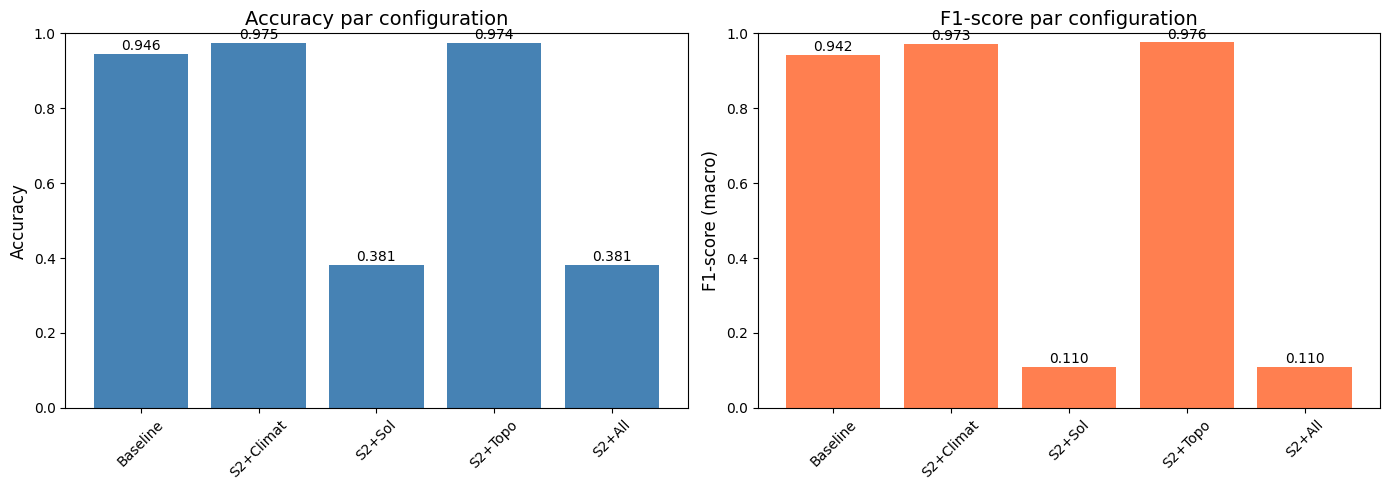

✅ Graphique sauvegardé: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\outputs/ablation_results.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = list(results.keys())
accs = [results[c]['accuracy'] for c in configs]
f1s = [results[c]['f1'] for c in configs]

axes[0].bar(configs, accs, color='steelblue')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy par configuration', fontsize=14)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
for bar, acc in zip(axes[0].patches, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.3f}', ha='center', fontsize=10)

axes[1].bar(configs, f1s, color='coral')
axes[1].set_ylabel('F1-score (macro)', fontsize=12)
axes[1].set_title('F1-score par configuration', fontsize=14)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)
for bar, f1 in zip(axes[1].patches, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{f1:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{output_path}/ablation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Graphique sauvegardé: {output_path}/ablation_results.png")

# Cellule 16 : Conclusion

In [23]:
print("\n" + "=" * 60)
print("CONCLUSION DE L'ABLATION STUDY")
print("=" * 60)

best_config = max(results, key=lambda x: results[x]['accuracy'])
best_acc = results[best_config]['accuracy']
best_f1 = results[best_config]['f1']

print(f"\n🏆 Meilleure configuration: {best_config}")
print(f"   Accuracy: {best_acc:.4f}")
print(f"   F1-score: {best_f1:.4f}")

print("\n📊 Analyse des gains par rapport à la baseline:")
for name, metrics in results.items():
    gain = metrics['accuracy'] - baseline_acc
    if gain > 0:
        print(f"   + {name}: +{gain:.4f} amélioration")
    elif gain < 0:
        print(f"   - {name}: {gain:.4f} (moins bon)")

print("\n✅ Partie 2 terminée !")


CONCLUSION DE L'ABLATION STUDY

🏆 Meilleure configuration: S2+Climat
   Accuracy: 0.9752
   F1-score: 0.9727

📊 Analyse des gains par rapport à la baseline:
   + S2+Climat: +0.0296 amélioration
   - S2+Sol: -0.5643 (moins bon)
   + S2+Topo: +0.0286 amélioration
   - S2+All: -0.5643 (moins bon)

✅ Partie 2 terminée !


VÉRIFICATION DES DONNÉES DE SOL

1. APERÇU DES DONNÉES SOL:
   soil_ph  soil_oc  soil_texture
0     76.0      2.0           4.0
1     73.0      2.0           4.0
2     74.0      2.0           4.0
3     75.0      2.0           4.0
4     73.0      3.0           4.0
5     73.0      2.0           7.0
6     74.0      2.0           4.0
7     75.0      2.0           4.0
8     72.0      3.0           4.0
9     73.0      2.0           7.0

2. STATISTIQUES PAR COLONNE:

soil_ph:
   Type: float64
   Min: 65.0
   Max: 81.0
   NaN: 12
   Inf: 0
   Valeurs uniques: 17
   Valeurs: [np.float64(65.0), np.float64(66.0), np.float64(67.0), np.float64(68.0), np.float64(69.0), np.float64(70.0), np.float64(71.0), np.float64(72.0), np.float64(73.0), np.float64(74.0), np.float64(75.0), np.float64(76.0), np.float64(77.0), np.float64(79.0), np.float64(nan), np.float64(78.0), np.float64(80.0), np.float64(81.0)]

soil_oc:
   Type: float64
   Min: 1.0
   Max: 10.0
   NaN: 12
   Inf: 0
   Valeurs uniques: 10
   Vale

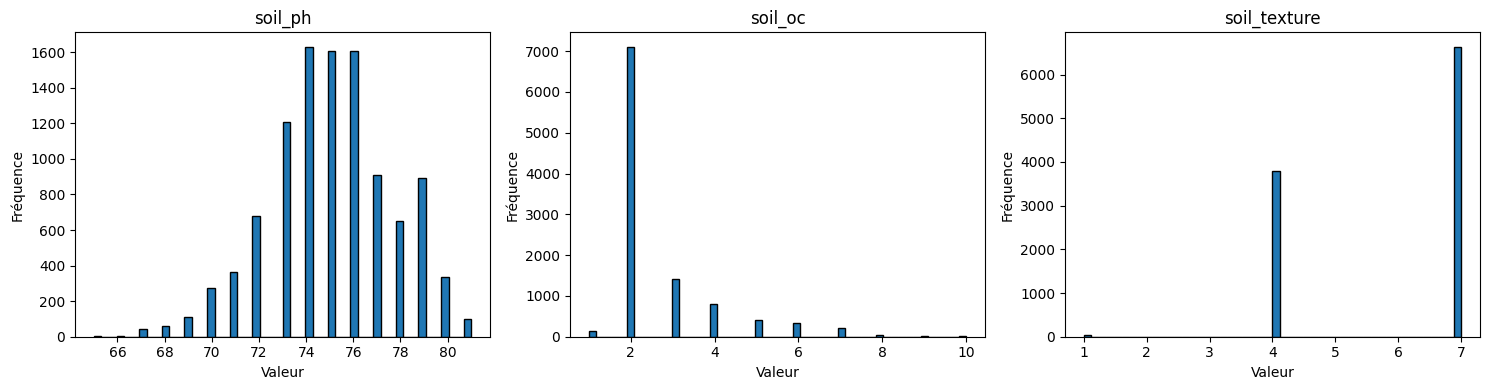

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("VÉRIFICATION DES DONNÉES DE SOL")
print("=" * 60)

# Charger les covariables
cov = pd.read_csv(r'C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part2\data\aligned\covariates.csv')

soil_cols = ['soil_ph', 'soil_oc', 'soil_texture']

print("\n1. APERÇU DES DONNÉES SOL:")
print(cov[soil_cols].head(10))

print("\n2. STATISTIQUES PAR COLONNE:")
for col in soil_cols:
    print(f"\n{col}:")
    print(f"   Type: {cov[col].dtype}")
    print(f"   Min: {cov[col].min()}")
    print(f"   Max: {cov[col].max()}")
    print(f"   NaN: {cov[col].isna().sum()}")
    print(f"   Inf: {np.isinf(cov[col]).sum()}")
    print(f"   Valeurs uniques: {cov[col].nunique()}")
    if cov[col].nunique() < 20:
        print(f"   Valeurs: {sorted(cov[col].unique())}")

print("\n3. VALEURS ABERRANTES (écart-type > 5):")
for col in ['soil_ph', 'soil_oc']:
    mean = cov[col].mean()
    std = cov[col].std()
    outliers = ((cov[col] - mean).abs() > 5 * std).sum()
    print(f"   {col}: {outliers} outliers")

print("\n4. TEST DE NORMALISATION:")
X_test = cov[soil_cols].values
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_test)
print(f"   Avant normalisation - min: {X_test.min():.4f}, max: {X_test.max():.4f}")
print(f"   Après normalisation - min: {X_norm.min():.4f}, max: {X_norm.max():.4f}")
print(f"   Moyenne: {X_norm.mean():.4f}, Écart-type: {X_norm.std():.4f}")

print("\n5. DISTRIBUTION DE soil_texture (variable catégorielle):")
texture_counts = cov['soil_texture'].value_counts().sort_index()
for val, count in texture_counts.items():
    print(f"   {val}: {count} points")

print("\n6. CORRÉLATION ENTRE VARIABLES SOL:")
corr = cov[soil_cols].corr()
print(corr)

# Visualisation rapide
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(soil_cols):
    axes[i].hist(cov[col].dropna(), bins=50, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')
plt.tight_layout()
plt.savefig('soil_distributions.png')
print("\n✅ Histogrammes sauvegardés dans 'soil_distributions.png'")

print("\n" + "=" * 60)
print("CONCLUSION:")
print("=" * 60)

# Détection des problèmes
problems = []
if cov[soil_cols].isna().sum().sum() > 0:
    problems.append("❌ Il y a des valeurs NaN")
if (cov[soil_cols] == -999).any().any():
    problems.append("❌ Il y a des valeurs -999 (souvent des valeurs manquantes)")
if cov['soil_texture'].nunique() < 10:
    problems.append("⚠️ soil_texture est catégorielle (peu de valeurs uniques)")
if (cov['soil_ph'] < 3).any() or (cov['soil_ph'] > 11).any():
    problems.append("⚠️ Des valeurs pH en dehors de la plage normale (3-11)")

if problems:
    print("\nProblèmes détectés:")
    for p in problems:
        print(f"   {p}")
    print("\n🔧 Correction recommandée:")
    print("   - Remplacer les valeurs manquantes par la médiane")
    print("   - Encoder soil_texture en one-hot (variable catégorielle)")
else:
    print("\n✅ Aucun problème majeur détecté")
    
print("\n📌 Les résultats anormaux (Accuracy=0.38) viennent probablement")
print("   de soil_texture qui est une variable catégorielle. Il faut")
print("   l'encoder en one-hot avant de l'utiliser.")